In [1]:
import pandas as pd

brokered by (categorically encoded agency/broker)

status (Housing status - a. ready for sale or b. ready to build)

price (Housing price, it is either the current listing price or recently sold price if the house is 
sold recently)

bed (# of beds)

bath (# of bathrooms)

acre_lot (Property / Land size in acres)

street (categorically encoded street address)

city (city name)

state (state name)

zip_code (postal code of the area)

house_size (house area/size/living space in square feet)

prev_sold_date (Previously sold date)


In [2]:
df = pd.read_csv('realtor-data.zip.csv')
df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2226377,23009.0,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,99354.0,3600.0,2022-03-25
2226378,18208.0,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,99354.0,1616.0,2022-03-25
2226379,76856.0,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,99354.0,3200.0,2022-03-24
2226380,53618.0,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,99354.0,933.0,2022-03-24


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          str    
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            str    
 8   state           str    
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  str    
dtypes: float64(8), str(4)
memory usage: 269.9 MB


In [4]:
df.describe().round()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2221849.0,2.224841e+06,1745065.0,1714611.0,1900793.0,2215516.0,2226083.0,1.657898e+06
mean,52940.0,5.241960e+05,3.0,2.0,15.0,1012325.0,52187.0,2.714000e+03
std,30643.0,2.138893e+06,2.0,2.0,763.0,583763.0,28954.0,8.081640e+05
min,0.0,0.000000e+00,1.0,1.0,0.0,0.0,0.0,4.000000e+00
25%,23861.0,1.650000e+05,3.0,2.0,0.0,506313.0,29617.0,1.300000e+03
50%,52884.0,3.250000e+05,3.0,2.0,0.0,1012766.0,48382.0,1.760000e+03
75%,79183.0,5.500000e+05,4.0,3.0,1.0,1521173.0,78070.0,2.413000e+03
max,110142.0,2.147484e+09,473.0,830.0,100000.0,2001357.0,99999.0,1.040400e+09


In [5]:
df.isna().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
# brokered_by : Broker/Agency encoded
# zip_code : Postal code
# prev_sold_date : Date when the property was sold

# Dropping the above columns as they are being seen as useless
df.drop(columns=['brokered_by','zip_code','prev_sold_date'],inplace=True)

In [9]:
df

,status,price,bed,bath,acre_lot,street,city,state,house_size
0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,920.0
1,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,1527.0
2,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,748.0
3,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,1800.0
4,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,NaN
...,...,...,...,...,...,...,...,...,...
2226377,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,3600.0
2226378,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,1616.0
2226379,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,3200.0
2226380,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,933.0


In [10]:
df.isna().sum()

status             0
price           1541
bed           481317
bath          511771
acre_lot      325589
street         10866
city            1407
state              8
house_size    568484
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(1356397, 9)

In [13]:
df['status'].value_counts()

status
for_sale    747914
sold        608483
Name: count, dtype: int64

Text(0, 0.5, 'Number of houses')

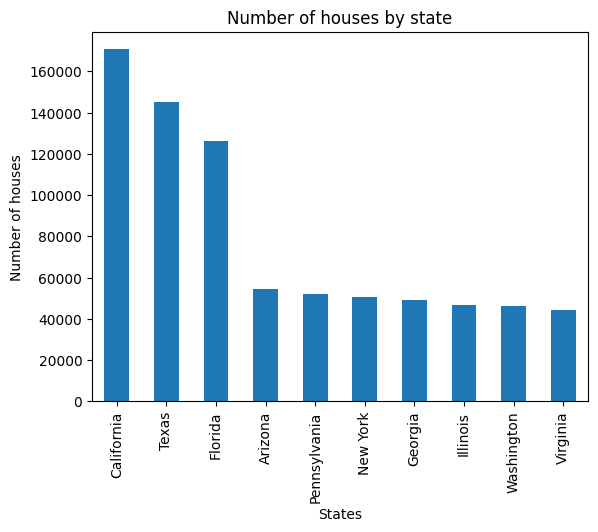

In [14]:
import matplotlib.pyplot as plt

df['state'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Number of houses by state")
plt.xlabel("States")
plt.ylabel("Number of houses")

In [15]:
df.groupby('state')['price'].mean().sort_values(ascending=False).astype(int)

state
Virgin Islands          1947522
Hawaii                  1491548
District of Columbia    1209649
California              1107565
Colorado                 952394
Utah                     915089
Montana                  863136
Connecticut              790499
Massachusetts            754151
Nevada                   751435
Washington               727478
Wyoming                  720054
Guam                     717504
Idaho                    690081
New York                 658206
Florida                  649952
Oregon                   645420
New Hampshire            640991
Puerto Rico              632210
Vermont                  557932
Arizona                  552887
Virginia                 546278
Alaska                   541288
New Jersey               541053
Maine                    517994
Rhode Island             511104
Maryland                 502873
Tennessee                485226
South Carolina           485074
Texas                    450836
South Dakota             440008
No

In [16]:
df.groupby('city')['price'].mean().sort_values(ascending=False).astype(int)

city
International      2147483600
Bolingbroke          45250000
Bal Harbour          26585714
Gulf Stream          21461250
Woody Creek          20987500
                      ...    
Otter Rock              10033
Midwest                 10000
Center Junction          8500
Rowan                    7500
Pilot Mound              6500
Name: price, Length: 17114, dtype: int64

In [17]:
df.groupby(['state','city'])['price'].mean().astype(int)

state    city      
Alabama  Abbeville      220154
         Adamsville     138441
         Addison        145950
         Adger          174372
         Akron          438940
                        ...   
Wyoming  Wheatland      281578
         Wilson        5719900
         Worland        288907
         Wright         291160
         Yoder          340666
Name: price, Length: 26260, dtype: int64

In [18]:
df.select_dtypes(include=['number']).corr()['price'].sort_values()

street        0.000472
acre_lot      0.005306
house_size    0.073868
bed           0.117596
bath          0.208898
price         1.000000
Name: price, dtype: float64

In [19]:
df.columns

Index(['status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state',
       'house_size'],
      dtype='str')

In [20]:
import numpy as np

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price'] >= Q1 - 1.5*IQR) & 
        (df['price'] <= Q3 + 1.5*IQR)]

print(f"Shape after removing outliers: {df.shape}")

df['price_log'] = np.log1p(df['price'])
df.dropna(inplace=True)
print(f"Shape after removing NA values: {df.shape}")

Shape after removing outliers: (1244200, 9)
Shape after removing NA values: (1244200, 10)


In [21]:
df['bed_bath_ratio']  = df['bed'] / (df['bath'] + 1)
df['size_per_bed']    = df['house_size'] / (df['bed'] + 1)

In [22]:
X = df[['bed','bath','house_size','acre_lot','status','city','state','street']]
y = df['price']

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['status', 'state', 'city']:
    X[col] = le.fit_transform(X[col].astype(str))

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [25]:
X_train

,bed,bath,house_size,acre_lot,status,city,state,street
2110515,4.0,3.0,1994.0,0.17,1,3224,4,1396813.0
1753922,4.0,4.0,3024.0,0.42,1,13985,44,40685.0
2167153,3.0,3.0,1745.0,0.09,1,12933,4,1773656.0
793152,3.0,3.0,2691.0,0.38,0,401,52,835588.0
2182960,3.0,3.0,1880.0,0.21,1,6678,38,1306746.0
...,...,...,...,...,...,...,...,...
238955,4.0,2.0,2028.0,0.21,0,10908,21,1309844.0
603319,4.0,2.0,1272.0,1.40,0,16272,0,458448.0
291960,3.0,2.0,1654.0,33.15,0,16455,34,1240283.0
1400640,2.0,2.0,1812.0,2.14,0,12384,50,785750.0


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [27]:
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)

X_train shape:  (995360, 8)
X_test shape:  (248840, 8)


In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

In [29]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

rf.fit(X_train_scaled,y_train)
y_pred2 = rf.predict(X_test_scaled)

In [32]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

C:\Users\namde\AppData\Local\Temp\ipykernel_2296\1849761239.py:1: RuntimeWarning: overflow encountered in expm1
  y_pred_actual = np.expm1(y_pred)


In [33]:
import joblib
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [34]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test_actual, y_pred_actual)

ValueError: Input contains infinity or a value too large for dtype('float64').

In [35]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred )

0.2197132830782469

In [36]:
df['price'].describe().astype(int)

count    1244200
mean      398700
std       231260
min            0
25%       225000
50%       350000
75%       529000
max      1141250
Name: price, dtype: int64